**Preliminari**

In [1]:
import sys
import os
from dotenv import load_dotenv
from pathlib import Path

from BERT_utils import create_label_to_id_map, labels_to_bits, bits_to_labels, NAN_VALUE, get_multiple_choice_fields, get_optional_regression_fields

# if notebook is in PRIN/notebooks, parent() is PRIN
#project_root = Path.cwd().resolve().parent
#sys.path.insert(0, str(project_root))
#print("Added to sys.path:", project_root)

import json
#from utils.schema_json import ReportData, AnnotatedReport
import time
from IPython.display import clear_output

from huggingface_hub import login

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, DefaultDataCollator
from datasets import load_dataset, Dataset, DatasetDict

from constants import AnnotatedReport, Annotations

from classifiers import ReportExtractor
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from ast import literal_eval
import loop
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
plt.style.use('ggplot')

**Impostiamo il device, scheda video se disponibile**

In [2]:
print(f'{torch.cuda.is_available() = }')  # True se la GPU è disponibile
print(f'{torch.cuda.device_count() = }')  # Numero di GPU disponibili
print(f'{torch.cuda.get_device_name(0) = }')  # Nome della GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'{device = }')

torch.cuda.is_available() = True
torch.cuda.device_count() = 1
torch.cuda.get_device_name(0) = 'NVIDIA GeForce GTX 1060 6GB'
device = device(type='cuda')


**Huggingface login**

In [3]:
# Set the API key for HuggingFace
load_dotenv()  # Load environment variables from .env file
hf_api_key = os.getenv("HF_TOKEN")
login(token=hf_api_key)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


**Parametri**

In [4]:
# Parameters
TRAIN_FILE_NAME = "train_split.csv"
VALIDATION_FILE_NAME = "validation_split.csv"

CHECKPOINT = "bert-base-multilingual-cased"

**Load data**

In [5]:
# Carichiamo i nostri file JSON
file_names = {
    'train': TRAIN_FILE_NAME,
    'validation': VALIDATION_FILE_NAME,
}

paths = {
    split: Path('../data/' + file_name) for split, file_name in file_names.items()
}

data = dict()
for split, path in paths.items():
    with open(path, "r", encoding="utf-8") as f:
        data[split] = pd.read_csv(f)

train_data, validation_data = data['train'], data['validation']

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")

len(train_data) = 116
len(validation_data) = 28


In [6]:
# Creiamo colonne per flag quando i campi numerici sono mancanti
for split, df in data.items():
    for col in get_optional_regression_fields(Annotations):
        new_name = f'{col}_is_nan'
        df[new_name] = df[col].isna()

In [7]:
data['train'].describe()

,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,linfonodi_sospetti,numero_depositi
count,47.000000,47.000000,21.000000,109.000000,104.000000,116.000000,116.000000
mean,9.127660,10.000000,21.095238,48.954128,46.961538,0.525862,0.051724
std,3.692631,3.611576,13.967479,17.905816,29.986704,1.042248,0.258586
min,1.000000,1.000000,7.000000,18.000000,0.000000,0.000000,0.000000
25%,6.000000,10.000000,13.000000,35.000000,25.000000,0.000000,0.000000
50%,12.000000,12.000000,15.000000,48.000000,50.000000,0.000000,0.000000
75%,12.000000,12.000000,22.000000,60.000000,70.000000,0.000000,0.000000
max,12.000000,12.000000,60.000000,130.000000,120.000000,4.000000,2.000000


In [8]:
data['train'].to_dict(orient='records')[0]

{'report_text': "SI SEGNALA LA PRESENZA IN CORRISPONDENZA DEL RETTO BASSO , DALLA GIUNZIONE RETTOANALE CON ESTENSIONE CRANIALE PER CIRCA 6 CM , DI UNA FORMAZIONE MODERATAMENTE IPERINTENSA NELLE SEQUENZE T2 DIPENDENTI CHE INTERESSA CIRCONFERENZIALMENTE IL RETTO BASSO ED INVIA DIGITAZIONI NEL MESORETTO UNA DELLE QUALI RAGGIUNGE, A SINISTRA, IL MUSCOLO ELAVATORE DELL'ANO DI SINISTRA. LUNGO I VASI EMORROIDARI SUPERIORI SONO PRESENTI ALCUNI LINFONODI I MAGGIORI DEL DIAMETRO DI CIRCA 1 CM. LINFONODI DI DIMENSIONI INFERIORI AD 1 CM IN SEDE INGUINALE BILATERALE. ESITI DI PREGRESSO INTERVENTO DI TURP. CONCLUSIONI:STADIAZIONE RM T4N1",
 'morfologia': 'solido_anulare',
 'posizione': "['basso']",
 'ore_inizio': 12.0,
 'ore_fine': 12.0,
 'spessore_parietale': nan,
 'estensione_cranio_caudale': 60.0,
 'distanza_oai': 0.0,
 'riflessione_peritoneale_anteriore': 'sotto',
 'infiltrazione_tessuto_adiposo': 'si_5mm_plus',
 'infiltrazione_sfinteri': nan,
 'infiltrazione_organi_extra': 'si',
 'infiltrazione

In [9]:
annotated_reports: dict[str, list[AnnotatedReport]] = {split: [] for split in file_names.keys()}
mc_fields = get_multiple_choice_fields(Annotations)
for split in data:
    df = data[split].fillna(NAN_VALUE)
    for _, row in df.iterrows():
        annotations_dict = dict()
        for field in Annotations.model_fields.keys():
            v = row[field]
            if v == NAN_VALUE:
                v = None
            if field in mc_fields:
                v = literal_eval(v)
            annotations_dict[field] = v
        annotated_reports[split].append(AnnotatedReport(report_text=row['report_text'], report_data=annotations_dict))

**Load model and tokenizer**

In [10]:
model = ReportExtractor().to(device)
tokenizer = AutoTokenizer.from_pretrained(model.checkpoint)

In [11]:
# Check the maximum number of tokens for each report
max_n_tokens_train = 0
del_train = []
for i, report in enumerate(annotated_reports['train']):
    x = tokenizer(report.report_text, return_tensors='pt')['input_ids'].shape[1]
    max_n_tokens_train = max(max_n_tokens_train, x)
    if x > model.encoder.config.max_position_embeddings:
        del_train.append(i)
print(del_train)
print(f'{max_n_tokens_train = }')

# Check the maximum number of tokens for each report
max_n_tokens_validation = 0
del_val = []
for i, report in enumerate(annotated_reports['validation']):
    x = tokenizer(report.report_text, return_tensors='pt')['input_ids'].shape[1]
    max_n_tokens_validation = max(max_n_tokens_validation, x)
    if x > model.encoder.config.max_position_embeddings:
        del_val.append(i)
print(del_val)
print(f'{max_n_tokens_validation = }')

# Delete long reports
for i in del_train[::-1]:
    annotated_reports['train'].pop(i)
for i in del_val[::-1]:
    annotated_reports['validation'].pop(i)
print('deleted')

Token indices sequence length is longer than the specified maximum sequence length for this model (612 > 512). Running this sequence through the model will result in indexing errors


[1, 4, 5, 8, 10, 11, 13, 17, 21, 31, 36, 39, 45, 49, 50, 64, 66, 69, 73, 75, 77, 78, 84, 86, 88, 89, 94, 95, 97, 98, 100, 103, 111, 112, 114, 115]
max_n_tokens_train = 1211
[0, 1, 2, 5, 6, 8, 9, 12, 13, 15, 16, 17, 21, 23, 24, 26, 27]
max_n_tokens_validation = 1799
deleted


In [12]:
def create_hugging_face_dataset(annotated_reports: list[AnnotatedReport]) -> Dataset:
    text = []
    for report in annotated_reports:
        text.append(report.report_text)
    return Dataset.from_dict({'text': text})

In [13]:
dataset = DatasetDict({
    'train': create_hugging_face_dataset(annotated_reports['train']),
    'validation': create_hugging_face_dataset(annotated_reports['validation'])
})

In [14]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", max_length=model.encoder.config.max_position_embeddings)

In [15]:
dataset = dataset.map(tokenize_function, batched=True)
dataset.set_format('torch')

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/11 [00:00<?, ? examples/s]

In [16]:
dataset = dataset.remove_columns(["token_type_ids", "text"])

In [17]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 80
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 11
    })
})


In [18]:
label_to_id_map = create_label_to_id_map(model.annotations_model)

In [19]:
# Classification fields
for f in model.classification_fields:
    for split in ('train', 'validation'):
        target: list[int] = []
        for r in annotated_reports[split]:
            label = getattr(r.report_data, f)
            if label is None:
                label = NAN_VALUE
            id = label_to_id_map[f]['label_to_id'][label]
            target.append(id)
        dataset[split] = dataset[split].add_column(f, target)

In [20]:
# Binary classification fields
for f in model.binary_classification_fields:
    for split in ('train', 'validation'):
        target: list[int] = []
        for r in annotated_reports[split]:
            label = getattr(r.report_data, f)
            id = label_to_id_map[f]['label_to_id'][label]
            target.append(id)
        dataset[split] = dataset[split].add_column(f, target)

In [21]:
# Regression fields
for f in model.regression_fields:
    for split in ('train', 'validation'):
        target: list[float] = []
        for r in annotated_reports[split]:
            value = getattr(r.report_data, f)
            if value is None:
                value = 0
            target.append(float(value))
        dataset[split] = dataset[split].add_column(f, target)

In [22]:
# Multiple choice fields
for f in model.multiple_choice_fields:
    for split in ('train', 'validation'):
        target: list[list[int]] = []
        for r in annotated_reports[split]:
            values = getattr(r.report_data, f)
            bits = labels_to_bits(values, label_to_id_map[f]['label_to_id'])
            target.append(bits)
        dataset[split] = dataset[split].add_column(f, target)

In [23]:
model.eval()
batch = dataset['train'][:2]
output = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))

In [24]:
# Esempio multiple choice
campo = 'posizione'
print(output[campo])
print(batch[campo])
print((nn.functional.sigmoid(output[campo]) > 0.5).int())
print(nn.functional.binary_cross_entropy_with_logits(output[campo], batch[campo].float().to(device)))

tensor([[0.2045, 0.0801, 0.1038, 0.2313],
        [0.2274, 0.2476, 0.1563, 0.0073]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([[1, 0, 0, 0],
        [0, 1, 1, 0]])
tensor([[1, 1, 1, 1],
        [1, 1, 1, 1]], device='cuda:0', dtype=torch.int32)
tensor(0.6996, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [25]:
# Esempio classificazione
campo = 'morfologia'
print(output[campo])
print(batch[campo])
print((nn.functional.softmax(output[campo], dim=1)))
print((nn.functional.softmax(output[campo], dim=1).argmax(dim=1)))
print(nn.functional.cross_entropy(output[campo], batch[campo].to(device)))

tensor([[-0.3098,  0.1323,  0.3959,  0.1074],
        [-0.0535, -0.1670,  0.2439,  0.0693]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
tensor([1, 1])
tensor([[0.1640, 0.2551, 0.3321, 0.2489],
        [0.2289, 0.2043, 0.3081, 0.2588]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([2, 2], device='cuda:0')
tensor(1.4771, device='cuda:0', grad_fn=<NllLossBackward0>)


In [26]:
# Esempio classificazione binaria
campo = 'numero_linfonodi_non_conosciuto'
print(output[campo])
print(batch[campo])
print((nn.functional.sigmoid(output[campo]) > 0.5).int())
print(nn.functional.binary_cross_entropy_with_logits(output[campo].squeeze(-1), batch[campo].float().to(device)))

tensor([[ 0.0817],
        [-0.2597]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([1, 0])
tensor([[1],
        [0]], device='cuda:0', dtype=torch.int32)
tensor(0.6124, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [27]:
# Esempio regressione
campo = 'distanza_oai'
print(output[campo])
print(batch[campo])
print(nn.functional.mse_loss(output[campo].squeeze(-1), batch[campo].to(device)))

tensor([[0.1096],
        [0.0000]], device='cuda:0', grad_fn=<ReluBackward0>)
tensor([  0., 100.])
tensor(5000.0059, device='cuda:0', grad_fn=<MseLossBackward0>)


# Training with pure PyTorch

In [39]:
model = ReportExtractor().to(device)
tokenizer = AutoTokenizer.from_pretrained(model.checkpoint)

In [40]:
# Se voglio allenare solo le teste di classificazione
for param in model.encoder.parameters():
    param.requires_grad = False

In [41]:
# Parametri totali
total_params = sum(p.numel() for p in model.parameters())

# Parametri allenabili (quelli con gradiente)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parametri totali: {total_params:,}")
print(f"Parametri allenabili: {trainable_params:,}")

Parametri totali: 177,915,729
Parametri allenabili: 62,289


In [42]:
out_feat = 0
for head in model.heads.values():
    out_feat += head.out_features
print(f'Parametri delle teste di estrazione: {model.encoder.config.hidden_size * out_feat + out_feat}')

Parametri delle teste di estrazione: 62289


In [43]:
# Training parameters
n_epochs = 20
batch_size = 4
learning_rate = 2e-3

In [44]:
loss = loop.train(
    model,
    dataset_train=dataset['train'],
    dataset_validation=dataset['validation'],
    epochs=n_epochs,
    batch_size=batch_size,
    lr=learning_rate,
    verbose=1
)

100%|██████████| 20/20 [00:04<00:00,  4.88it/s]


Epoch 1/20 - Training loss: 165.6327
Validation loss: 103.0516


100%|██████████| 20/20 [00:04<00:00,  4.97it/s]


Epoch 2/20 - Training loss: 141.8943
Validation loss: 87.0877


100%|██████████| 20/20 [00:04<00:00,  4.99it/s]


...

Epoch 18/20 - Training loss: 55.8378
Validation loss: 36.6967


100%|██████████| 20/20 [00:04<00:00,  4.88it/s]


Epoch 19/20 - Training loss: 57.5263
Validation loss: 36.8878


100%|██████████| 20/20 [00:04<00:00,  4.93it/s]


Epoch 20/20 - Training loss: 54.4911
Validation loss: 36.7787


Text(0, 0.5, 'Loss')

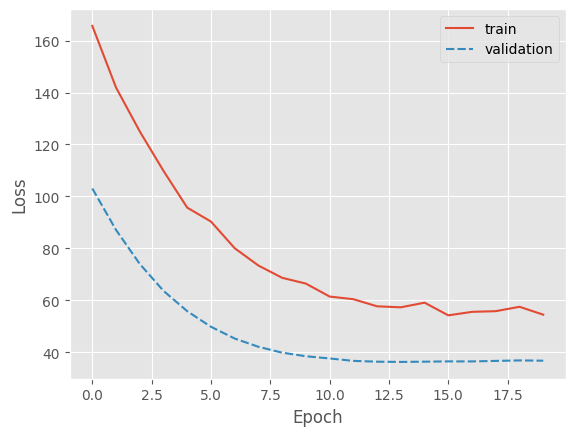

In [48]:
sns.lineplot(data=pd.DataFrame(loss))
plt.xlabel('Epoch')
plt.ylabel('Loss')